 ## Step 1: Imports
                                

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt


In [108]:
# Load data from the csv file into a DataFrame and save in a variable

df = pd.read_csv(r"C:\Users\AL HAFIZ COMPUTER\Documents\lab files\Files\Unicorn_Companies.csv")

## Step 2: Data exploration


In [109]:
# Display the first 10 rows of the data                                                
df.head(10)

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors
0,Bytedance,$180B,4/7/17,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$100B,12/1/12,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100B,7/3/18,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95B,1/23/14,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG"
4,Klarna,$46B,12/12/11,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita..."
5,Canva,$40B,1/8/18,Internet software & services,Surry Hills,Australia,Oceania,2012,$572M,"Sequoia Capital China, Blackbird Ventures, Mat..."
6,Checkout.com,$40B,5/2/19,Fintech,London,United Kingdom,Europe,2012,$2B,"Tiger Global Management, Insight Partners, DST..."
7,Instacart,$39B,12/30/14,"Supply chain, logistics, & delivery",San Francisco,United States,North America,2012,$3B,"Khosla Ventures, Kleiner Perkins Caufield & By..."
8,JUUL Labs,$38B,12/20/17,Consumer & retail,San Francisco,United States,North America,2015,$14B,Tiger Global Management
9,Databricks,$38B,2/5/19,Data management & analytics,San Francisco,United States,North America,2013,$3B,"Andreessen Horowitz, New Enterprise Associates..."


In [84]:
# How large the dataset is

df.size

10740

In [85]:
# Shape of the dataset

df.shape

(1074, 10)

In [86]:
# Get information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Company           1074 non-null   object
 1   Valuation         1074 non-null   object
 2   Date Joined       1074 non-null   object
 3   Industry          1074 non-null   object
 4   City              1058 non-null   object
 5   Country/Region    1074 non-null   object
 6   Continent         1074 non-null   object
 7   Year Founded      1074 non-null   int64 
 8   Funding           1074 non-null   object
 9   Select Investors  1073 non-null   object
dtypes: int64(1), object(9)
memory usage: 84.0+ KB


 ## Step 3: Statistical tests


In [87]:
### Get descriptive statistics

df.describe()

,Year Founded
count,1074.000000
mean,2012.895717
std,5.698573
min,1919.000000
25%,2011.000000
50%,2014.000000
75%,2016.000000
max,2021.000000


In [107]:
# Step 1. Use pd.to_datetime() to convert Date Joined column to datetime 
# Step 2. Update the column with the converted values

df["Date Joined"] = pd.to_datetime(df["Date Joined"], errors="coerce")

In [89]:
# Use .info() to confirm that the update actually took place

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1074 entries, 0 to 1073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Company           1074 non-null   object        
 1   Valuation         1074 non-null   object        
 2   Date Joined       1074 non-null   datetime64[ns]
 3   Industry          1074 non-null   object        
 4   City              1058 non-null   object        
 5   Country/Region    1074 non-null   object        
 6   Continent         1074 non-null   object        
 7   Year Founded      1074 non-null   int64         
 8   Funding           1074 non-null   object        
 9   Select Investors  1073 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 84.0+ KB


In [90]:
# Step 1: Use .dt.year to extract year component from Date Joined column
# Step 2: Add the result as a new column named Year Joined to the DataFrame


df["Year Joined"] = df["Date Joined"].dt.year

In [91]:
# Use .head() to confirm that the new column did get added

df.head()

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined
0,Bytedance,$180B,2017-04-07,Artificial intelligence,Beijing,China,Asia,2012,$8B,"Sequoia Capital China, SIG Asia Investments, S...",2017
1,SpaceX,$100B,2012-12-01,Other,Hawthorne,United States,North America,2002,$7B,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2012
2,SHEIN,$100B,2018-07-03,E-commerce & direct-to-consumer,Shenzhen,China,Asia,2008,$2B,"Tiger Global Management, Sequoia Capital China...",2018
3,Stripe,$95B,2014-01-23,Fintech,San Francisco,United States,North America,2010,$2B,"Khosla Ventures, LowercaseCapital, capitalG",2014
4,Klarna,$46B,2011-12-12,Fintech,Stockholm,Sweden,Europe,2005,$4B,"Institutional Venture Partners, Sequoia Capita...",2011


 ## Step 4: Results and evaluation
                                           

In [93]:
# Take a sample of the data
# Use the sample() function for this task.

df_sample = df.sample(n = 50, random_state =42)


###  Visualize the time it took companies to reach unicorn status

In [94]:


# Prepare data for plotting

# Create new `years_till_unicorn` column
df_sample["Years_still_unicorn"] = df_sample["Year Joined"]-df_sample["Year Founded"]


# Group the data by `Industry`. For each industry, get the max value in the `years_till_unicorn` column.
grouped = (df_sample[["Industry", "Years_still_unicorn"]]
           .groupby("Industry")
           .max()
           .sort_values(by= "Years_still_unicorn")
          )
        
grouped


,Years_still_unicorn
Industry,
Consumer & retail,1
Auto & transportation,2
Artificial intelligence,5
Data management & analytics,8
Mobile & telecommunications,9
"Supply chain, logistics, & delivery",12
Internet software & services,13
Other,15
E-commerce & direct-to-consumer,18


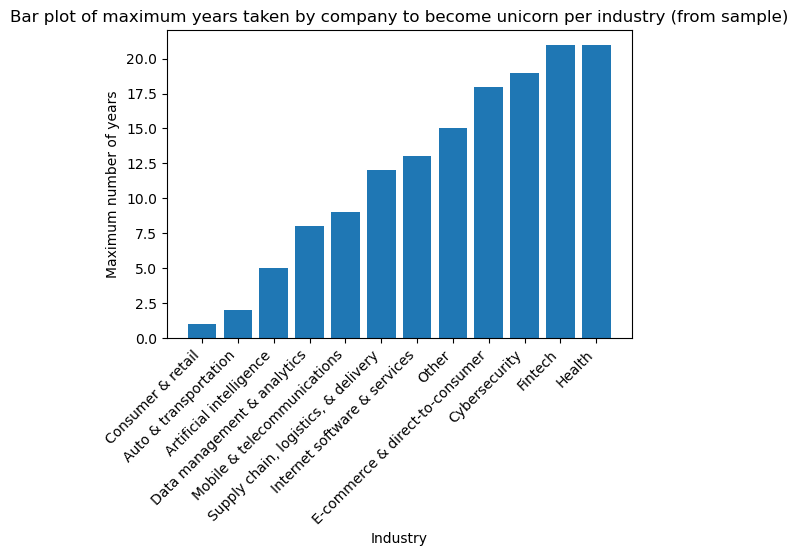

In [95]:
# Create bar plot
# with Industry column as the categories of the bars
# and the difference in years between Year Joined column and Year Founded column as the heights of the bars

# maintain size oe figur
plt.figure(figsize=(6,4))


plt.bar(grouped.index , grouped["Years_still_unicorn"] )

# Set title
plt.title("Bar plot of maximum years taken by company to become unicorn per industry (from sample)")

# Set x-axis label
plt.xlabel ("Industry")

# Set y-axis label
plt.ylabel ("Maximum number of years")

# Rotate labels on the x-axis as a way to avoid overlap in the positions of the text 
plt.xticks(rotation=45, horizontalalignment= "right")

# Display the plot
plt.show()




###  Visualize the maximum unicorn company valuation per industry

In [97]:
# Create a column representing company valuation as numeric data

# Create new column
df_sample["valuation billions"] = df_sample["Valuation"]

# Remove the '$' from each value
df_sample["valuation billions"] = df_sample["valuation billions"].str.replace("$", "")

# Remove the 'B' from each value
df_sample["valuation billions"] = df_sample["valuation billions"].str.replace("B", "")

# Convert column to type int
df_sample["valuation billions"] = df_sample["valuation billions"].astype("int")

# Display the plot
df_sample.head()

,Company,Valuation,Date Joined,Industry,City,Country/Region,Continent,Year Founded,Funding,Select Investors,Year Joined,Years_still_unicorn,valuation billions
542,Aiven,$2B,2021-10-18,Internet software & services,Helsinki,Finland,Europe,2016,$210M,"Institutional Venture Partners, Atomico, Early...",2021,5,2
370,Jusfoun Big Data,$2B,2018-07-09,Data management & analytics,Beijing,China,Asia,2010,$137M,"Boxin Capital, DT Capital Partners, IDG Capital",2018,8,2
307,Innovaccer,$3B,2021-02-19,Health,San Francisco,United States,North America,2014,$379M,"M12, WestBridge Capital, Lightspeed Venture Pa...",2021,7,3
493,Algolia,$2B,2021-07-28,Internet software & services,San Francisco,United States,North America,2012,$334M,"Accel, Alven Capital, Storm Ventures",2021,9,2
350,SouChe Holdings,$3B,2017-11-01,E-commerce & direct-to-consumer,Hangzhou,China,Asia,2012,$1B,"Morningside Ventures, Warburg Pincus, CreditEa...",2017,5,3


In [100]:
# Prepare data for modeling

grouped = (df_sample[["Industry", "valuation billions"]]
           .groupby("Industry")
           .max()
           .sort_values(by = "valuation billions")
          )
grouped
           



,valuation billions
Industry,
Auto & transportation,1
Consumer & retail,1
Other,2
"Supply chain, logistics, & delivery",2
Cybersecurity,3
Health,3
Data management & analytics,4
E-commerce & direct-to-consumer,4
Internet software & services,5


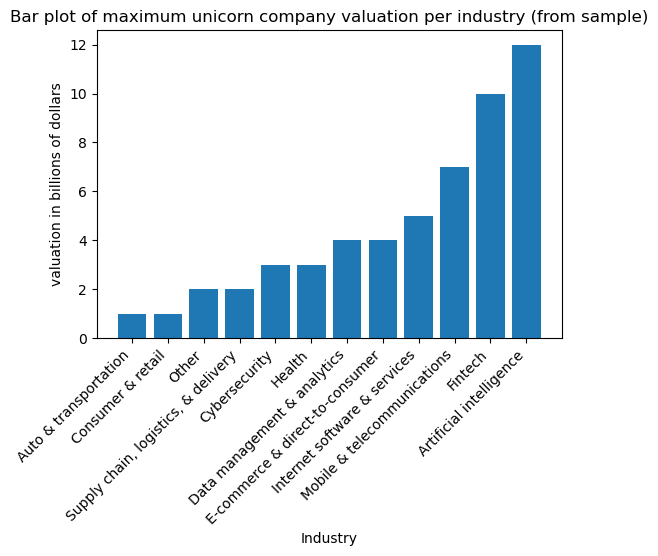

In [111]:
# Create bar plot
# with Industry column as the categories of the bars
# and new valuation column as the heights of the bars



plt.figure(figsize=(6,4))
plt.bar  (grouped. index , grouped ["valuation billions"])


# Set title
plt.title ("Bar plot of maximum unicorn company valuation per industry (from sample)")

# Set x-axis label
plt.xlabel  ("Industry")

# Set y-axis label
plt.ylabel  ("valuation in billions of dollars")


# Rotate labels on the x-axis as a way to avoid overlap in the positions of the text
plt.xticks  (rotation = 45, horizontalalignment = "right")

# Display the plot
plt.show()


## Final Insight:

The dataset contains 1,074 unicorn companies. Analysis suggests that some companies took longer to achieve unicorn status but have reached very high valuations by March 2022. This indicates that rapid growth is not the only path to success; companies with longer development periods can also generate significant value. For investment decisions, stakeholders should focus on industry-specific analysis and identify high-valuation companies with relatively fewer investors, as these may represent strong future investment opportunities.
